# Action Distribution Analysis
Datasets: R2R, Human, RxR, ScanQA

Actions: STOP (0), FORWARD (1), TURN_LEFT (2), TURN_RIGHT (3)

In [1]:
import json
import re
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

DATASET_PATHS = {
    "R2R":    "/home/rithvik/IROS_proj/NaVILA-Dataset/R2R/annotations.json",
    "Human":  "/home/rithvik/IROS_proj/NaVILA-Dataset/Human/annotations.json",
    "RxR":    "/home/rithvik/IROS_proj/NaVILA-Dataset/RxR/annotations.json",
    "ScanQA": "/home/rithvik/IROS_proj/NaVILA-Dataset/ScanQA/annotations/ScanQA_v1.0_train_reformat.json",
}

ACTIONS = ["STOP", "FORWARD", "TURN_LEFT", "TURN_RIGHT", "OTHER"]
COLORS  = ["#e74c3c", "#2ecc71", "#3498db", "#f39c12", "#95a5a6"]

def classify_action(answer):
    """Mirrors action_codes_from_answer logic from data_processor_gru.py"""
    if isinstance(answer, list):
        answer = answer[0] if answer else ""
    a = (answer or "").lower()
    if "right" in a:        return "TURN_RIGHT"
    if "left" in a:         return "TURN_LEFT"
    if "forward" in a:      return "FORWARD"
    if "stop" in a:         return "STOP"
    return "OTHER"

In [2]:
# Load all datasets (run once — results cached in `dataset_counts`)
dataset_counts = {}

for name, path in DATASET_PATHS.items():
    print(f"Loading {name} ...", end=" ", flush=True)
    with open(path) as f:
        data = json.load(f)
    counter = Counter(classify_action(item["a"]) for item in data)
    dataset_counts[name] = counter
    total = sum(counter.values())
    print(f"{total:,} items — ", end="")
    print({k: f"{v:,} ({100*v/total:.1f}%)" for k, v in sorted(counter.items())})

print("\nDone.")

Loading R2R ... 353,894 items — {'FORWARD': '171,449 (48.4%)', 'STOP': '32,457 (9.2%)', 'TURN_LEFT': '78,323 (22.1%)', 'TURN_RIGHT': '71,665 (20.3%)'}
Loading Human ... 557,546 items — {'FORWARD': '289,912 (52.0%)', 'STOP': '99,100 (17.8%)', 'TURN_LEFT': '83,574 (15.0%)', 'TURN_RIGHT': '84,960 (15.2%)'}
Loading RxR ... 417,578 items — {'FORWARD': '211,379 (50.6%)', 'STOP': '33,300 (8.0%)', 'TURN_LEFT': '96,529 (23.1%)', 'TURN_RIGHT': '76,370 (18.3%)'}
Loading ScanQA ... 25,563 items — {'FORWARD': '9 (0.0%)', 'OTHER': '22,380 (87.5%)', 'TURN_LEFT': '1,442 (5.6%)', 'TURN_RIGHT': '1,732 (6.8%)'}

Done.


In [3]:
# ── Per-dataset breakdown table ──────────────────────────────────────────────
print(f"{'Dataset':<10}  {'Total':>8}  ", end="")
for a in ACTIONS:
    print(f"{a:>12}", end="")
print()
print("-" * 80)

totals_all = Counter()
for name, counter in dataset_counts.items():
    total = sum(counter.values())
    totals_all += counter
    print(f"{name:<10}  {total:>8,}  ", end="")
    for a in ACTIONS:
        pct = 100 * counter.get(a, 0) / total
        print(f"{pct:>11.1f}%", end="")
    print()

print("-" * 80)
grand_total = sum(totals_all.values())
print(f"{'ALL':<10}  {grand_total:>8,}  ", end="")
for a in ACTIONS:
    pct = 100 * totals_all.get(a, 0) / grand_total
    print(f"{pct:>11.1f}%", end="")
print()

Dataset        Total          STOP     FORWARD   TURN_LEFT  TURN_RIGHT       OTHER
--------------------------------------------------------------------------------
R2R          353,894          9.2%       48.4%       22.1%       20.3%        0.0%
Human        557,546         17.8%       52.0%       15.0%       15.2%        0.0%
RxR          417,578          8.0%       50.6%       23.1%       18.3%        0.0%
ScanQA        25,563          0.0%        0.0%        5.6%        6.8%       87.5%
--------------------------------------------------------------------------------
ALL         1,354,581         12.2%       49.7%       19.2%       17.3%        1.7%


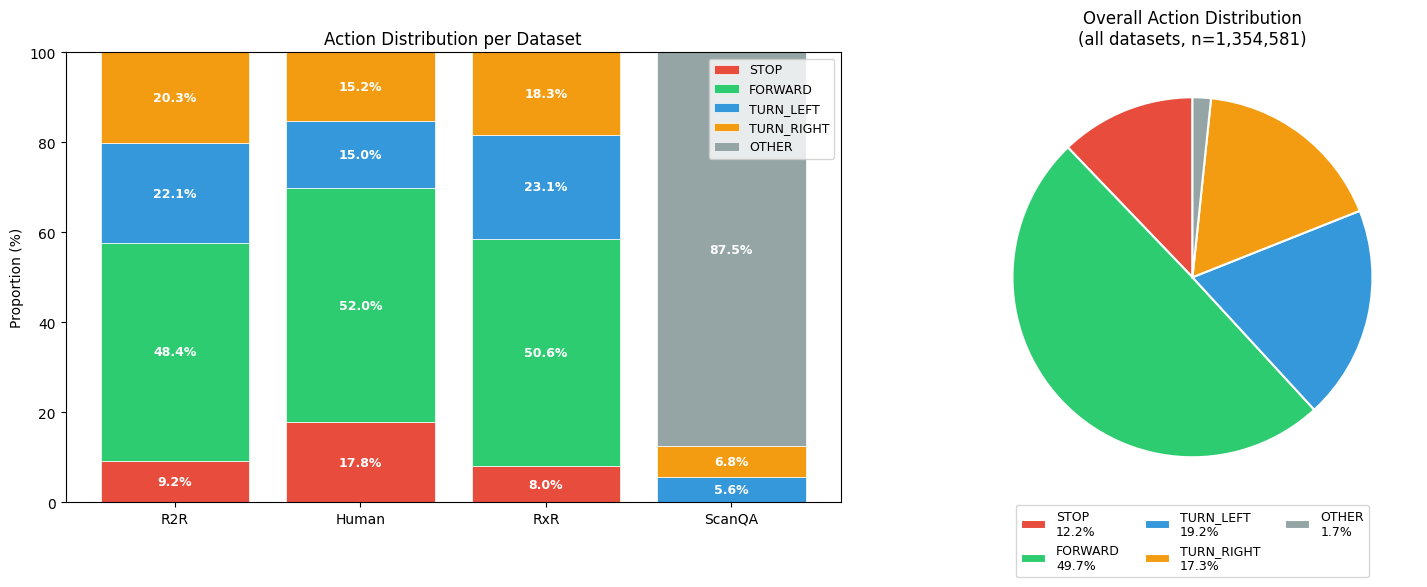

Saved to action_distribution.png


In [4]:
# ── Figure: per-dataset stacked bar + overall pie ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: stacked bar per dataset ---
ax = axes[0]
ds_names = list(dataset_counts.keys())
bottoms = np.zeros(len(ds_names))

for i, (action, color) in enumerate(zip(ACTIONS, COLORS)):
    vals = []
    for name in ds_names:
        total = sum(dataset_counts[name].values())
        vals.append(100 * dataset_counts[name].get(action, 0) / total)
    bars = ax.bar(ds_names, vals, bottom=bottoms, color=color, label=action, edgecolor="white", linewidth=0.5)
    # label if slice is wide enough
    for j, (bar, v) in enumerate(zip(bars, vals)):
        if v > 3:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bottoms[j] + v/2,
                    f"{v:.1f}%",
                    ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottoms += np.array(vals)

ax.set_ylim(0, 100)
ax.set_ylabel("Proportion (%)")
ax.set_title("Action Distribution per Dataset")
ax.legend(loc="upper right", fontsize=9)

# --- Right: pie for combined (navigation datasets only) ---
ax2 = axes[1]
nav_total = Counter()
for name in ["R2R", "Human", "RxR"]:
    nav_total += dataset_counts[name]

# combine with ScanQA for full combined
combined = totals_all
sizes  = [combined.get(a, 0) for a in ACTIONS]
labels = [f"{a}\n{100*s/grand_total:.1f}%" for a, s in zip(ACTIONS, sizes)]
wedges, _ = ax2.pie(sizes, colors=COLORS, startangle=90,
                     wedgeprops=dict(edgecolor="white", linewidth=1.5))
ax2.legend(wedges, labels, loc="lower center", bbox_to_anchor=(0.5, -0.18),
           ncol=3, fontsize=9)
ax2.set_title(f"Overall Action Distribution\n(all datasets, n={grand_total:,})")

plt.tight_layout()
plt.savefig("action_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to action_distribution.png")

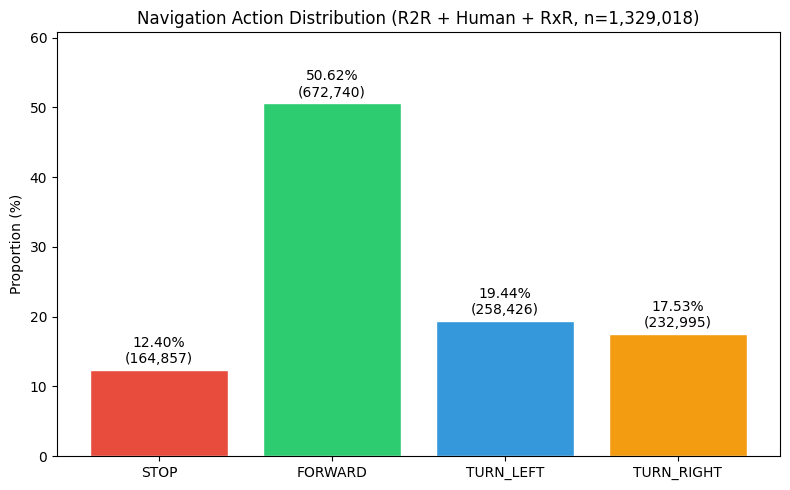

Saved to action_distribution_nav_only.png


In [5]:
# ── Navigation-only (R2R + Human + RxR) combined breakdown ───────────────────
fig, ax = plt.subplots(figsize=(8, 5))

nav_names = ["R2R", "Human", "RxR"]
nav_combined = Counter()
for name in nav_names:
    nav_combined += dataset_counts[name]

nav_total_n = sum(nav_combined.values())
nav_actions = [a for a in ACTIONS if a != "OTHER"]
nav_colors  = COLORS[:4]

counts = [nav_combined.get(a, 0) for a in nav_actions]
pcts   = [100 * c / nav_total_n for c in counts]
bars   = ax.bar(nav_actions, pcts, color=nav_colors, edgecolor="white", linewidth=1)

for bar, pct, cnt in zip(bars, pcts, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{pct:.2f}%\n({cnt:,})",
            ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Proportion (%)")
ax.set_title(f"Navigation Action Distribution (R2R + Human + RxR, n={nav_total_n:,})")
ax.set_ylim(0, max(pcts) * 1.2)
plt.tight_layout()
plt.savefig("action_distribution_nav_only.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to action_distribution_nav_only.png")